In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [2]:
df = pd.read_csv(r"C:\\Users\\HP\\NLP_Bhavik\\Sentiment_Data\\Sentiment_Data.csv", encoding="ISO-8859-1")


In [3]:
df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [4]:
df.dtypes

Tweet        object
Sentiment    object
dtype: object

In [5]:
# Print the first few lines of the "Sentiment" column
print(df['Sentiment'].head())


0    Mild_Pos
1    Mild_Pos
2    Mild_Pos
3    Mild_Pos
4    Mild_Pos
Name: Sentiment, dtype: object


In [6]:
# Initialize stop words and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Iterate over the rows in the 'Tweet' column
for index, row in df.iterrows():
    text = str(row['Tweet'])  # Ensure the text is a string

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    
    # Remove mentions (usernames)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Tokenization: Split text into words
    words = word_tokenize(text)
    
    # Remove stop words
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization: Convert words to their base form
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the words back into a single string and update the row
    df.at[index, 'Tweet'] = ' '.join(words)

# Display the first few rows to see the results
print(df[['Tweet', 'Sentiment']].head())

                                               Tweet Sentiment
0  happy anniversarythe day freedumb died tune mc...  Mild_Pos
1  happy anniversarythe day freedumb died tune mc...  Mild_Pos
2  happy anniversarythe day freedumb died tune mc...  Mild_Pos
3  happy anniversarythe day freedumb died tune mc...  Mild_Pos
4  happy anniversarythe day freedumb died tune mc...  Mild_Pos


In [7]:
df.columns = df.columns.str.strip()

In [8]:
# Check for NaN values and any other anomalies in the 'Sentiment' column
print(df['Sentiment'].isna().sum())  # Check how many NaN values
print(df['Sentiment'].head())  # Inspect the first few values in the 'Sentiment' column

0
0    Mild_Pos
1    Mild_Pos
2    Mild_Pos
3    Mild_Pos
4    Mild_Pos
Name: Sentiment, dtype: object


# Emoji Handling

In [9]:
def remove_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F700-\U0001F77F"  # Alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric symbols
        u"\U0001F800-\U0001F8FF"  # Supplemental symbols
        u"\U0001F900-\U0001F9FF"  # Additional symbols
        u"\U0001FA00-\U0001FA6F"  # Symbols for emoji components
        u"\U0001FA70-\U0001FAFF"  # Additional symbols
        u"\U00002702-\U000027B0"  # Dingbats
        "]+", flags=re.UNICODE)
    
    return emoji_pattern.sub(r'', text)

# Apply function
df['Tweet'] = df['Tweet'].apply(remove_emojis)


# Slang Handling

In [10]:
slang_dict = {
    "brb": "be right back",
    "btw": "by the way",
    "dm": "direct message",
    "fyi": "for your information",
    "idk": "I do not know",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "lmao": "laughing my ass off",
    "lol": "laugh out loud",
    "nvm": "never mind",
    "omg": "oh my god",
    "rofl": "rolling on the floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "ttyl": "talk to you later",
    "wth": "what the heck",
    "wyd": "what are you doing",
    "wym": "what you mean",
    "yeet": "throw something with force",
    "xoxo": "hugs and kisses",
    "hmu": "hit me up",
    "sus": "suspicious",
    "cap": "lie",
    "no cap": "not lying",
    "rn": "right now",
    "clout": "influence or fame",
    "fomo": "fear of missing out",
    "finna": "fixing to, about to",
    "lowkey": "quietly or secretly",
    "highkey": "not secretly, obviously",
    "lit": "amazing, cool",
    "mood": "relatable feeling",
    "vibe": "atmosphere or feeling",
    "stan": "overly obsessed fan",
    "savage": "bold or ruthless",
    "woke": "socially aware",
    "ghosting": "suddenly ignoring someone",
    "salty": "bitter or upset",
    "simp": "overly attentive to someone",
    "thirsty": "desperate for attention",
    "flex": "showing off",
    "bop": "good song",
    "banger": "great song or event",
    "drip": "stylish or fashionable",
    "gucci": "good, okay",
    "dope": "cool",
    "bet": "okay, agreed",
    "tea": "gossip or drama",
    "big yikes": "very embarrassing",
    "extra": "over the top",
    "shook": "shocked or surprised",
    "goat": "greatest of all time",
    "dead": "laughing hard",
    "hundo p": "100 percent",
    "af": "as f***",
    "wp": "well played",
    "gg": "good game",
    "ggwp": "good game, well played",
    "irl": "in real life",
    "afk": "away from keyboard",
    "rekt": "totally destroyed",
    "lag": "slow internet response",
    "op": "overpowered",
    "nerf": "make weaker",
    "buff": "make stronger",
    "tryhard": "someone who plays too seriously",
    "ez": "easy win",
    "grind": "working hard for progress",
    "pog": "amazing or exciting",
    "poggers": "even more amazing",
    "wtf": "what the f***",
    "idc": "I do not care",
    "idgaf": "I do not give a f***",
    "ftw": "for the win",
    "np": "no problem",
    "sksksk": "expression of excitement or laughter",
    "and i oop": "reaction to something surprising",
    "basic": "mainstream, unoriginal",
    "bff": "best friends forever",
    "boomer": "old person with outdated opinions",
    "clapback": "a clever comeback",
    "karens": "entitled or rude person",
    "boi": "boy",
    "dm me": "direct message me",
    "irl": "in real life",
    "rekt": "totally destroyed",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "wyd": "what you doing",
    "wym": "what you mean",
    "fr": "for real",
    "on god": "I swear",
    "g2g": "got to go",
    "bih": "variation of b****",
    "luv": "love",
    "tmw": "tomorrow",
    "frfr": "for real, for real",
    "idc": "I do not care",
    "lmk": "let me know",
    "tgif": "thank god it’s Friday",
    "nsfw": "not safe for work",
    "sfw": "safe for work",
    "doe": "though",
    "ion": "I don’t",
    "y’all": "you all",
    "bro": "brother",
    "fam": "family",
    "sry": "sorry",
    "wtf": "what the f***",
    "wbu": "what about you",
    "roflmao": "rolling on the floor laughing my ass off",
    "stfu": "shut the f*** up",
    "gn": "good night",
    "gm": "good morning",
    "ily": "I love you",
    "ily2": "I love you too",
    "nfs": "not for sale",
    "bih": "variation of b****",
    "gr8": "great",
    "thx": "thanks",
    "omw": "on my way",
    "ppl": "people",
    "tl;dr": "too long; didn’t read",
    "fml": "f*** my life",
    "hand": "have a nice day",
    "jsyk": "just so you know",
    "ptfo": "passed the f*** out",
    "rn": "right now",
    "ikr": "I know, right?",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "gg": "good game",
    "bg": "bad game",
    "ffs": "for f***’s sake",
    "ggno": "good game, no offense",
    "l8r": "later",
    "np": "no problem",
    "w/e": "whatever",
    "u2": "you too",
    "idc": "I don’t care",
    "wth": "what the heck",
    "yolo": "you only live once",
    "atm": "at the moment",
    "jk": "just kidding",
    "g2g": "got to go",
}


In [11]:
def replace_slang(text):
    words = text.split()
    new_text = " ".join([slang_dict[word.lower()] if word.lower() in slang_dict else word for word in words])
    return new_text

# Apply to tweets
df['Tweet'] = df['Tweet'].apply(replace_slang)

# Abbreviation Handling

In [12]:
abbreviation_dict = {
    "u": "you",
    "r": "are",
    "y": "why",
    "abt": "about",
    "asap": "as soon as possible",
    "b4": "before",
    "b/c": "because",
    "cuz": "because",
    "btw": "by the way",
    "dm": "direct message",
    "esp": "especially",
    "fav": "favorite",
    "fwd": "forward",
    "govt": "government",
    "gr8": "great",
    "idk": "I do not know",
    "ikr": "I know, right?",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "lmk": "let me know",
    "msg": "message",
    "nvm": "never mind",
    "pls": "please",
    "plz": "please",
    "ppl": "people",
    "thx": "thanks",
    "ty": "thank you",
    "ttyl": "talk to you later",
    "w/o": "without",
    "w/": "with",
    "wth": "what the heck",
    "ya": "you",
    "y'all": "you all",
    "yolo": "you only live once",
    "atm": "at the moment",
    "bff": "best friends forever",
    "brb": "be right back",
    "cu": "see you",
    "fyi": "for your information",
    "gg": "good game",
    "g2g": "got to go",
    "hmu": "hit me up",
    "icymi": "in case you missed it",
    "idc": "I do not care",
    "lmao": "laughing my ass off",
    "lol": "laugh out loud",
    "nsfw": "not safe for work",
    "omg": "oh my god",
    "rn": "right now",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "tl;dr": "too long; didn’t read",
    "ttfn": "ta-ta for now",
    "tysm": "thank you so much",
    "wyd": "what are you doing",
    "wym": "what you mean",
    "xoxo": "hugs and kisses",
    "bday": "birthday",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "np": "no problem",
    "ftw": "for the win",
    "ily": "I love you",
    "ilu": "I love you",
    "jk": "just kidding",
    "ggwp": "good game, well played",
    "pov": "point of view",
    "fomo": "fear of missing out",
    "fr": "for real",
    "bruh": "brother",
    "cap": "lie",
    "no cap": "not lying",
    "sus": "suspicious",
    "bt": "but",
    "tho": "though",
    "gg": "good game",
    "op": "overpowered",
    "afk": "away from keyboard",
    "irl": "in real life",
    "wp": "well played",
    "jk": "just kidding",
    "ikr": "I know, right?",
}
def replace_abbreviations(text):
    words = text.split()
    new_text = " ".join([abbreviation_dict[word.lower()] if word.lower() in abbreviation_dict else word for word in words])
    return new_text

# Apply to tweets
df['Tweet'] = df['Tweet'].apply(replace_abbreviations)

In [13]:
# Define a mapping for sentiment
sentiment_mapping = {
    'Mild_Pos': 'positive',
    'Mild_Neg': 'negative',
    'Neutral': 'neutral',
    'Strong_Pos': 'positive',
    'Strong_Neg': 'negative'
}

# Apply this mapping to the 'Sentiment' column
df['Sentiment'] = df['Sentiment'].map(sentiment_mapping)

# Check the unique values again
print(df['Sentiment'].unique())
df.columns = df.columns.str.strip()

['positive' 'neutral' 'negative']


In [14]:
# Now encode the mapped sentiments
df['Sentiment_Encoded'] = df['Sentiment'].map({'positive': 1, 'neutral': 0, 'negative': 2})

# Check the unique values in the encoded column
print(df['Sentiment_Encoded'].unique())


[1 0 2]


In [15]:
df

,Tweet,Sentiment,Sentiment_Encoded
0,happy anniversarythe day freedumb died tune mc...,positive,1
1,happy anniversarythe day freedumb died tune mc...,positive,1
2,happy anniversarythe day freedumb died tune mc...,positive,1
3,happy anniversarythe day freedumb died tune mc...,positive,1
4,happy anniversarythe day freedumb died tune mc...,positive,1
...,...,...,...
451327,gaza peace n freedom viva palestina convoy ent...,positive,1
451328,face defense soldier find freedom you fight fr...,positive,1
451329,face defense soldier find freedom you fight fr...,positive,1
451330,gaza peace n freedom israel stop aid convoy en...,positive,1


In [16]:
# Tokenize the tweet texts
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['Tweet'])  # Use 'Tweet' instead of 'tweet'
X = tokenizer.texts_to_sequences(df['Tweet'])

# Pad the sequences
max_length = max([len(tweet.split()) for tweet in df['Tweet']])  # Find the max length of a tweet
X = pad_sequences(X, maxlen=max_length, padding='post')

In [17]:
y = df['Sentiment_Encoded']


In [18]:
y

0         1
1         1
2         1
3         1
4         1
         ..
451327    1
451328    1
451329    1
451330    1
451331    1
Name: Sentiment_Encoded, Length: 451332, dtype: int64

In [19]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [20]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import numpy as np

# Reshape X_train and X_test to 3D if needed
# (samples, timesteps=1, features)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))  # (samples, timesteps, features)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))  # (samples, timesteps, features)

# Initialize the model
model = Sequential()

# Add the first LSTM layer
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))  # (timesteps, features)
model.add(Dropout(0.2))

# Add additional LSTM layers (deep architecture)
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=32))  # Last LSTM layer without return_sequences
model.add(Dropout(0.2))

# Output layer (for classification)
model.add(Dense(units=1, activation='sigmoid'))  # For binary classification

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,505 (599.63 KB)

 Trainable params: 153,505 (599.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
11284/11284 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - accuracy: 0.6798 - loss: -1.6188 - val_accuracy: 0.6829 - val_loss: -6.6299
Epoch 2/5
11284/11284 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - accuracy: 0.6831 - loss: -8.3973 - val_accuracy: 0.6826 - val_loss: -13.5342
Epoch 3/5
11284/11284 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - accuracy: 0.6834 - loss: -15.0387 - val_accuracy: 0.6826 - val_loss: -20.5458
Epoch 4/5
11284/11284 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - accuracy: 0.6818 - loss: -21.1903 - val_accuracy: 0.6829 - val_loss: -27.4474
Epoch 5/5
11284/11284 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - accuracy: 0.6804 - loss: -28.6988 - val_accuracy: 0.6830 - val_loss: -34.7556
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6828 - loss: -36.4825
Test Loss: -34.75556564331055, Test Accuracy: 0.6829849481582642


11284/11284 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


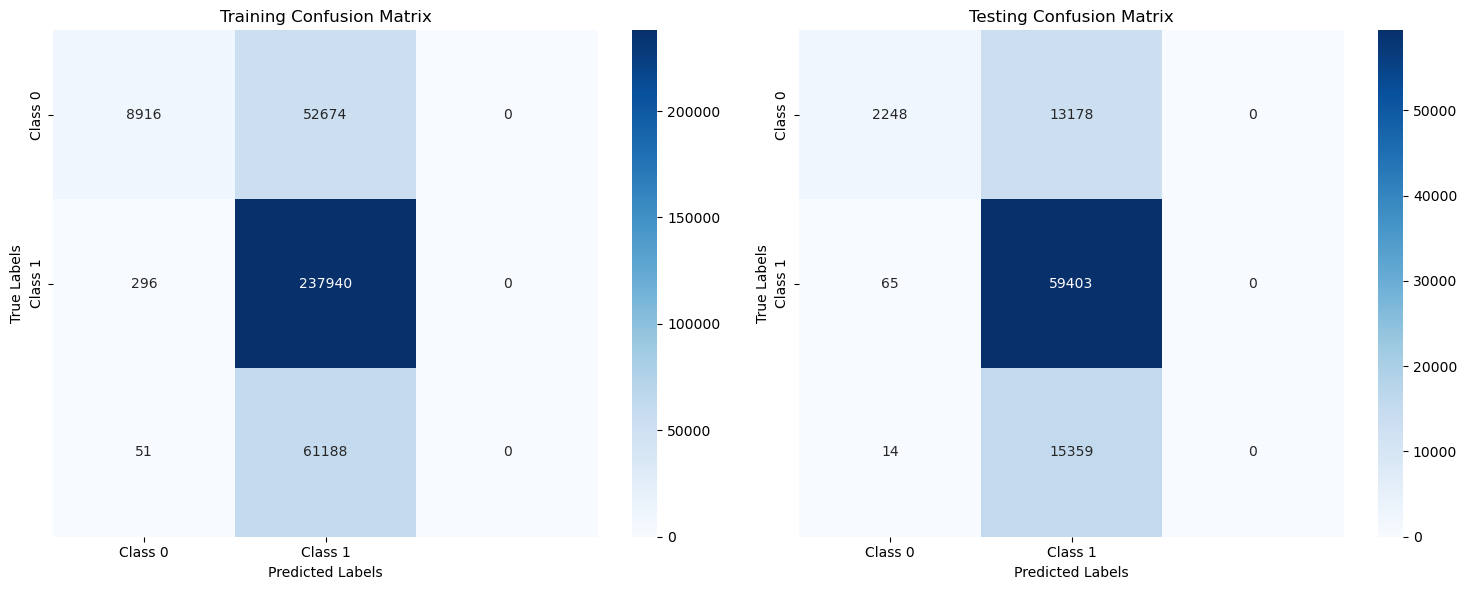

Training Confusion Matrix:
 [[  8916  52674      0]
 [   296 237940      0]
 [    51  61188      0]]
Testing Confusion Matrix:
 [[ 2248 13178     0]
 [   65 59403     0]
 [   14 15359     0]]


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Make predictions on both training and test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Step 2: Convert predictions to binary class labels (threshold at 0.5)
y_pred_train_classes = (y_pred_train > 0.5).astype("int32")
y_pred_test_classes = (y_pred_test > 0.5).astype("int32")

# Step 3: Calculate confusion matrices for both training and testing
cm_train = confusion_matrix(y_train, y_pred_train_classes)
cm_test = confusion_matrix(y_test, y_pred_test_classes)

# Step 4: Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=axes[0])
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')
axes[0].set_title('Training Confusion Matrix')

# Testing confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=axes[1])
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')
axes[1].set_title('Testing Confusion Matrix')

plt.tight_layout()
plt.show()

# Optionally print the confusion matrices
print("Training Confusion Matrix:\n", cm_train)
print("Testing Confusion Matrix:\n", cm_test)


In [22]:
from sklearn.metrics import f1_score

# Step 1: Calculate F1 Score for Training Data (multiclass F1 scores)
f1_train = f1_score(y_train, y_pred_train_classes, average=None)

# Step 2: Calculate F1 Score for Testing Data (multiclass F1 scores)
f1_test = f1_score(y_test, y_pred_test_classes, average=None)

# Step 3: Print the F1 Scores for each class
print("Training F1 Scores (per class):", f1_train)
print("Testing F1 Scores (per class):", f1_test)


Training F1 Scores (per class): [0.25167601 0.80652433 0.        ]
Testing F1 Scores (per class): [0.25325297 0.80596711 0.        ]


# Cross Validation

In [31]:
import numpy as np
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

# Convert y_train to a NumPy array if it's a pandas Series
y_train = y_train.values if isinstance(y_train, pd.Series) else y_train

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Loop through KFold splits
for train_index, val_index in kf.split(X_train):
    # Split the data
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # Check the shape of the fold data before reshaping
    print(f"Shape of X_train_fold: {X_train_fold.shape}")  # Print to check shape

    # Reshape data for LSTM - assuming X_train_fold is (samples, features)
    # Make sure X_train_fold has the shape (samples, features)
    if X_train_fold.ndim == 2:  # Ensure it's a 2D array
        X_train_fold = np.reshape(X_train_fold, (X_train_fold.shape[0], 1, X_train_fold.shape[1]))  # (samples, timesteps=1, features)
        X_val_fold = np.reshape(X_val_fold, (X_val_fold.shape[0], 1, X_val_fold.shape[1]))
    else:
        print("Unexpected shape of data. Please check the shape of X_train_fold.")

    # Initialize the model
    model = Sequential()
    
    # Add the first LSTM layer
    model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train_fold.shape[1], X_train_fold.shape[2])))  # (timesteps, features)
    model.add(Dropout(0.2))
    
    # Add additional LSTM layers (deep architecture)
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.2))

    model.add(LSTM(units=32))  # Last LSTM layer without return_sequences
    model.add(Dropout(0.2))

    # Output layer (for classification)
    model.add(Dense(units=1, activation='sigmoid'))  # For binary classification

    # Compile the model
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train the model
    model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, validation_data=(X_val_fold, y_val_fold))
    
    # Evaluate the model on the validation fold
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold)
    print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")


Shape of X_train_fold: (288852, 1, 50)
Unexpected shape of data. Please check the shape of X_train_fold.


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - accuracy: 0.6783 - loss: -1.3119 - val_accuracy: 0.6850 - val_loss: -5.1128
Epoch 2/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - accuracy: 0.6827 - loss: -6.5514 - val_accuracy: 0.6851 - val_loss: -10.1407
Epoch 3/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - accuracy: 0.6817 - loss: -12.0454 - val_accuracy: 0.6849 - val_loss: -15.5198
Epoch 4/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.6814 - loss: -17.7670 - val_accuracy: 0.6849 - val_loss: -20.8582
Epoch 5/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.6833 - loss: -22.9396 - val_accuracy: 0.6847 - val_loss: -25.5237
2257/2257 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6872 - loss: -26.6029
Validation Loss: -25.52373695373535, Validation Accuracy: 0.6847382187843323
Shape of X_train_fold: (288852, 1, 50)
Unexpected shape of data. Please check the shape of X_train_fold.
Epoch 1/5
9027/9027 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - accuracy: 0.6793